By **Difa F. Hakim**

---



---



#1. Installing PySCF

In [1]:
!pip install pyscf==2.11.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 MB 10.7 MB/s eta 0:00:00


#2. H-atom input file

In [2]:
from pyscf import gto, scf

# Define the molecule (Hydrogen atom)
mol = gto.Mole()
mol.atom = 'H 0 0 0'  # Hydrogen at the origin
mol.basis = 'STO-3G'   # Minimal basis set
mol.spin = 1           # Spin-polarized (unpaired electron)
mol.build()

# Perform Restricted Open-Shell Hartree-Fock (ROHF) calculation
mf = scf.ROHF(mol)
mf.kernel()  # Run the calculation

# Print results
print(f"Total Energy for Hydrogen Atom with STO-3G (Hartree): {mf.e_tot}")

converged SCF energy = -0.466581849557275
Total Energy for Hydrogen Atom with STO-3G (Hartree): -0.46658184955727533


#3. Helium-input file

## 4. a)Hartree-Fock/STO-3G for He

In [3]:
from pyscf import gto, scf

# Define the molecule (Helium atom)
mol = gto.Mole()
mol.atom = 'He 0 0 0'  # Helium at the origin
mol.basis = 'sto-3G'   # Minimal basis set
mol.charge = 0         # Neutral helium
mol.spin = 0           # Closed-shell (all electrons paired)
mol.build()

# Perform Restricted Hartree-Fock (RHF) calculation
mf = scf.RHF(mol)
mf.kernel()  # Run the calculation

# Print results
print("\n--- Hartree-Fock (STO-3G) Results for Helium Atom ---")
print(f"Total Energy (Hartree): {mf.e_tot}")

converged SCF energy = -2.80778395753997

--- Hartree-Fock (STO-3G) Results for Helium Atom ---
Total Energy (Hartree): -2.807783957539974


##5. b)Full Configuration Interaction/cc-pV5Z for He

In [4]:
from pyscf import gto, scf, fci

# Define the molecule (Helium atom)
mol = gto.Mole()
mol.atom = 'He 0 0 0'  # Helium at the origin
mol.basis = 'cc-pV5Z'    # Minimal basis set
mol.charge = 0          # Neutral helium
mol.spin = 0            # Closed-shell (all electrons paired)
mol.build()

# Run Hartree-Fock (HF) first to get MOs
mf = scf.RHF(mol)
mf.kernel()

# Perform Full CI (FCI) calculation
cisolver = fci.FCI(mol, mf.mo_coeff)
fci_energy, fci_vec = cisolver.kernel()

# Print results
print("\n--- FCI/cc-pV5Z Results for Helium Atom ---")
print(f"FCI Energy (cc-pV5Z): {fci_energy}")

converged SCF energy = -2.86162483458191

--- FCI/cc-pV5Z Results for Helium Atom ---
FCI Energy (cc-pV5Z): -2.9031518840489303


#6. H2 input file

##7. a)Hartree-Fock/STO-3G for H2

In [5]:
from pyscf import gto, scf

# Define molecular system
mol = gto.Mole()
mol.atom = '''
H 0 0 0
H 0 0 1.4
'''
mol.basis = 'sto-3g'
mol.charge = 0
mol.spin = 0  # singlet
mol.build()

# Perform Hartree-Fock calculation
mf = scf.RHF(mol)
mf.kernel()

# Print results
print("\nHF/STO-3G calculation for H2 at R=1.4 bohr")
print("Total Energy (Hartree):", mf.e_tot)

converged SCF energy = -0.941480654707799

HF/STO-3G calculation for H2 at R=1.4 bohr
Total Energy (Hartree): -0.9414806547077987


##7. b)Full Configuration Interaction/STO-3G for H2

In [6]:
from pyscf import gto, scf, fci

# Define molecular system
mol = gto.Mole()
mol.atom = '''
H 0 0 0.000
H 0 0 1.400
'''
mol.basis = 'sto-3G'
mol.charge = 0
mol.spin = 0  # singlet
mol.unit = 'Bohr'
mol.build()

# Perform Hartree-Fock calculation first
mf = scf.RHF(mol)
mf.kernel()

# Perform Full CI calculation
cisolver = fci.FCI(mol, mf.mo_coeff)
fci_energy_sto3gH2 = cisolver.kernel()[0]

# Print results
print("\nFCI/sto-3g calculation for H2 at R=1.4 bohr")
print("FCI Energy (Hartree):", fci_energy_sto3gH2)

converged SCF energy = -1.11671432506255

FCI/sto-3g calculation for H2 at R=1.4 bohr
FCI Energy (Hartree): -1.1372759436170439


##8. b)Full Configuration Interaction/cc-pV5Z for H2

In [7]:
from pyscf import gto, scf, fci

# Define molecular system
mol = gto.Mole()
mol.atom = '''
H 0 0 0.000
H 0 0 1.400
'''
mol.basis = 'cc-pVQZ'  # Very large basis set for high accuracy
mol.charge = 0
mol.spin = 0  # singlet
mol.unit = 'Bohr'
mol.build()

# Perform Hartree-Fock calculation first
mf = scf.RHF(mol)
mf.kernel()

# Perform Full CI calculation
cisolver = fci.FCI(mol, mf.mo_coeff)
fci_energy = cisolver.kernel()[0]

# Print results
print("\nFCI/cc-pV5Z calculation for H2 at R=1.4 bohr")
print("FCI Energy (Hartree):", fci_energy)

converged SCF energy = -1.13345903359425

FCI/cc-pV5Z calculation for H2 at R=1.4 bohr
FCI Energy (Hartree): -1.1737957922495084


#9. H2: 2nd Quantization Hamiltonian

In [8]:
!pip install pyscf==2.11.0 qiskit==1.4.5 qiskit-nature==0.7.2 qiskit-aer==0.17.2 pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 18.3 MB/s eta 0:00:00


In [9]:
import numpy as np
import pandas as pd

from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCC, HartreeFock

from qiskit import transpile
from qiskit_algorithms import NumPyMinimumEigensolver, VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as AerEstimator

from qiskit.circuit.library import TwoLocal
from qiskit.circuit import QuantumCircuit

In [10]:
def UCCSD_decompose(ansatz):

    N_iter = len(ansatz.decompose(reps=2).data)
    num_qubit = ansatz.num_qubits
    for i in range(N_iter):
        new_qc = QuantumCircuit(num_qubit)
        instruction = ansatz.decompose(reps=2).data[i]
        name = ansatz.decompose(reps=2).data[i][0].name
        print(i, name)
        new_qc.append(instruction)
        display(new_qc.decompose().draw('mpl'))

In [11]:
H2_driver = PySCFDriver(
        atom='H 0 0 0; H 0 0 1.4',
        basis='sto3g',
        charge=0,
        spin=0,
        unit=DistanceUnit.BOHR,
    )

In [12]:
problem = H2_driver.run()
hamiltonian = problem.hamiltonian
second_q_op = hamiltonian.second_q_op()
enuc = hamiltonian.nuclear_repulsion_energy

print(second_q_op,'\n')

Fermionic Operator
number spin orbitals=4, number terms=36
  -1.2527970618358173 * ( +_0 -_0 )
+ -0.4756022993742511 * ( +_1 -_1 )
+ -1.2527970618358173 * ( +_2 -_2 )
+ -0.4756022993742511 * ( +_3 -_3 )
+ 0.3372970421616846 * ( +_0 +_0 -_0 -_0 )
+ 0.3317819956102741 * ( +_0 +_1 -_1 -_0 )
+ 0.3372970421616846 * ( +_0 +_2 -_2 -_0 )
+ 0.3317819956102741 * ( +_0 +_3 -_3 -_0 )
+ 0.0906289573965542 * ( +_0 +_0 -_1 -_1 )
+ 0.0906289573965542 * ( +_0 +_1 -_0 -_1 )
+ 0.0906289573965542 * ( +_0 +_2 -_3 -_1 )
+ 0.0906289573965542 * ( +_0 +_3 -_2 -_1 )
+ 0.0906289573965542 * ( +_1 +_0 -_1 -_0 )
+ 0.0906289573965542 * ( +_1 +_1 -_0 -_0 )
+ 0.0906289573965542 * ( +_1 +_2 -_3 -_0 )
+ 0.0906289573965542 * ( +_1 +_3 -_2 -_0 )
+ 0.3317819956102741 * ( +_1 +_0 -_0 -_1 )
+ 0.34874767334009116 * ( +_1 +_1 -_1 -_1 )
+ 0.3317819956102741 * ( +_1 +_2 -_2 -_1 )
+ 0.34874767334009116 * ( +_1 +_3 -_3 -_1 )
+ 0.3372970421616846 * ( +_2 +_0 -_0 -_2 )
+ 0.3317819956102741 * ( +_2 +_1 -_1 -_2 )
+ 0.3372970421616846 

#10. H2: Qubit Hamiltonian

In [13]:
num_spatial_orbitals = problem.num_spatial_orbitals
num_particles = problem._num_particles
qubit = JordanWignerMapper().map(second_q_ops = second_q_op)
n_qubit = qubit.num_qubits
print(qubit.to_list(array=True))

[('IIII', -0.81244197+0.j) ('IIIZ',  0.17128249+0.j)
 ('IIZI', -0.2230402 +0.j) ('IZII',  0.17128249+0.j)
 ('ZIII', -0.2230402 +0.j) ('IIZZ',  0.12057652+0.j)
 ('IZIZ',  0.16864852+0.j) ('ZIIZ',  0.165891  +0.j)
 ('YYYY',  0.04531448+0.j) ('XXYY',  0.04531448+0.j)
 ('YYXX',  0.04531448+0.j) ('XXXX',  0.04531448+0.j)
 ('IZZI',  0.165891  +0.j) ('ZIZI',  0.17437384+0.j)
 ('ZZII',  0.12057652+0.j)]


#11. Classical/Numpy solver

In [14]:
numpy_solver = NumPyMinimumEigensolver()
np_result = numpy_solver.compute_minimum_eigenvalue(operator=qubit)
E_np = np_result.eigenvalue.real
E_total = E_np + enuc

print('Numpy Energy:',E_total)

Numpy Energy: -1.1372759436170439


#12. H2: Hardware-Efficient Ansatz

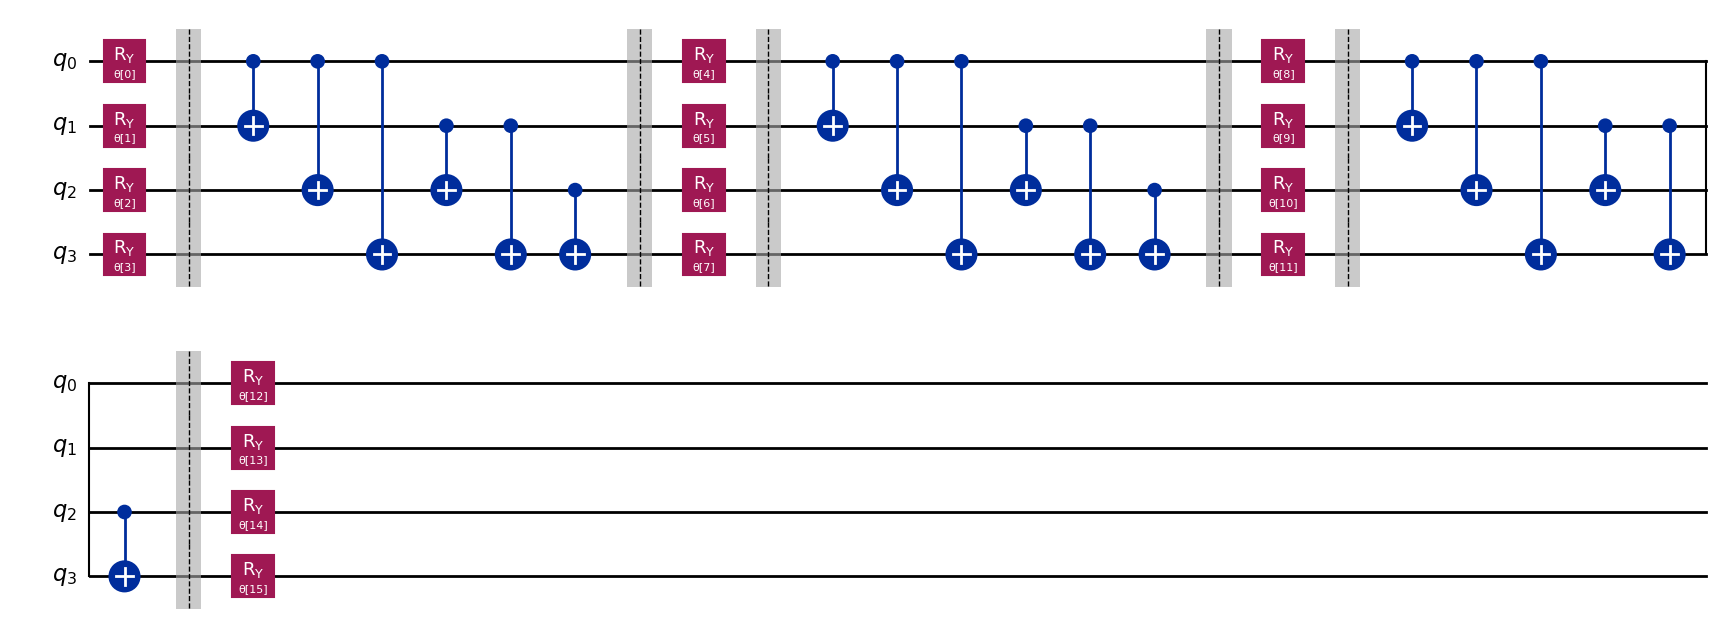

In [15]:
ansatz_HEA = TwoLocal(
                 num_qubits=n_qubit,
                 rotation_blocks="ry",
                 entanglement_blocks="cx",
                 entanglement='full',
                 reps=3,
                 insert_barriers=True,
                 parameter_prefix='θ')

# Transform quantum circuit into standard gate of specific quantum device/ simulator
backend = AerSimulator()
ansatz_HEA_t = transpile(ansatz_HEA,
                           backend=backend,
                           optimization_level=3)

vqe_HEA = VQE(AerEstimator(), ansatz_HEA_t, COBYLA())
res_HEA = vqe_HEA.compute_minimum_eigenvalue(operator=qubit)
display(ansatz_HEA_t.draw('mpl'))

#13. H2: UCCSD

In [16]:
ansatz_UCCSD = UCC(
        num_spatial_orbitals,
        num_particles,
        'sd',
        JordanWignerMapper(),
        initial_state=HartreeFock(
            num_spatial_orbitals,
            num_particles,JordanWignerMapper()))

ansatz_UCCSD_t = transpile(ansatz_UCCSD,
                           backend=backend,
                           optimization_level=3)

vqe_UCCSD = VQE(AerEstimator(),
                ansatz_UCCSD_t,
                COBYLA())
res_UCCSD = vqe_UCCSD.compute_minimum_eigenvalue(operator=qubit)

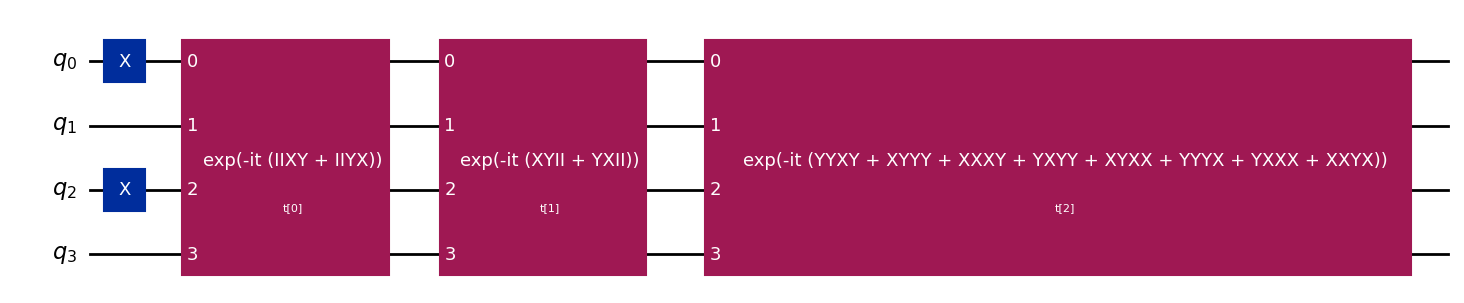

In [17]:
ansatz_UCCSD.decompose().draw('mpl')

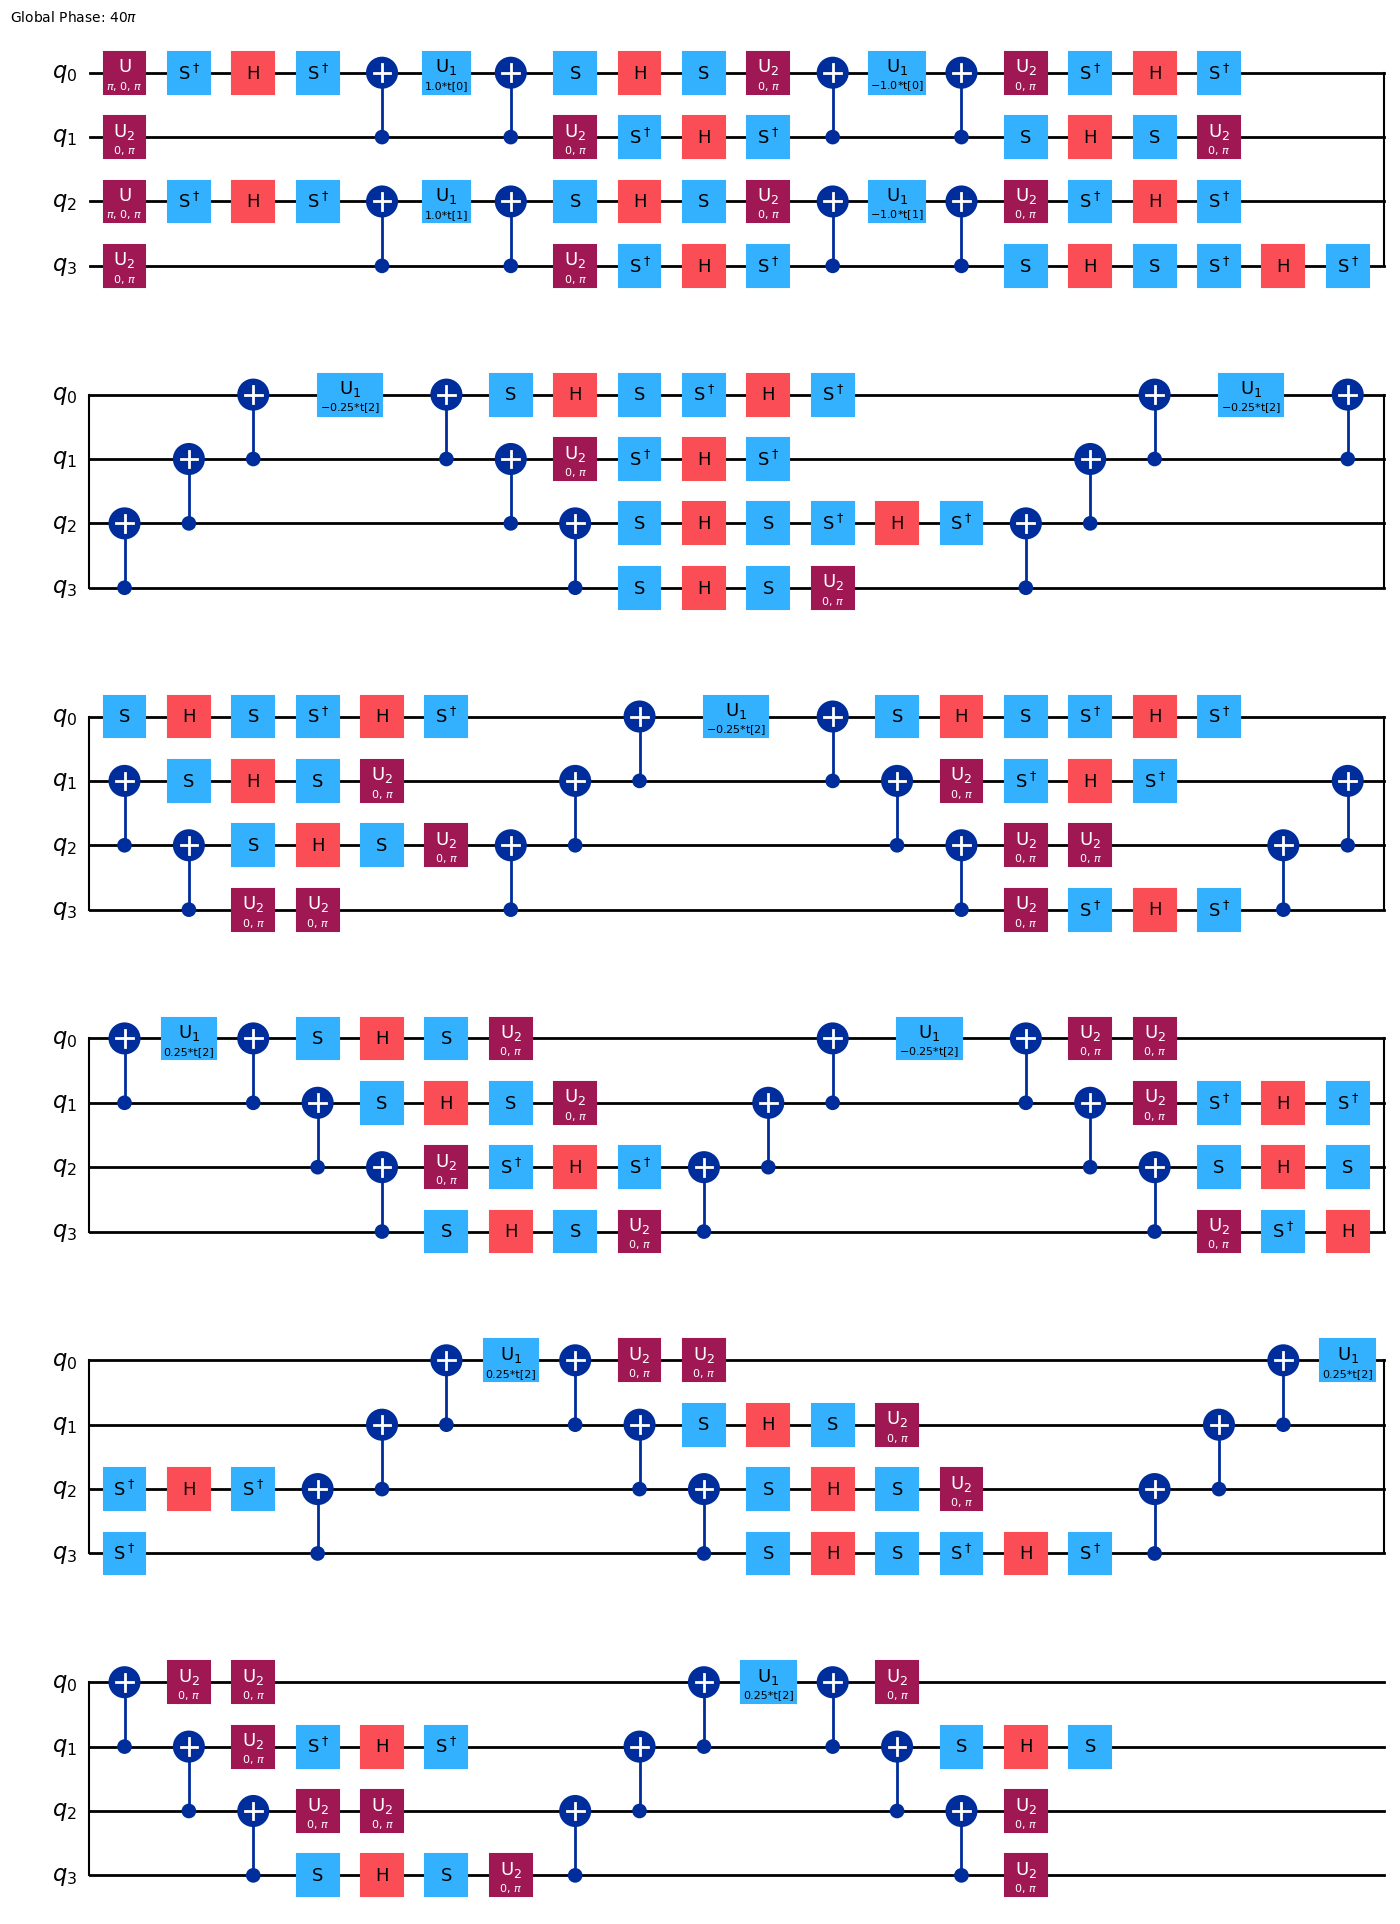

In [18]:
ansatz_UCCSD.decompose(reps=3).draw('mpl', fold=20)

#14. Comparison of Results

In [19]:
E_HEA = res_HEA.optimal_value + enuc
print('HEA Energy:',E_HEA)
print(res_HEA._optimal_point)

E_UCCSD = res_UCCSD.optimal_value + enuc
print('UCCSD Energy :',E_UCCSD)

HEA Energy: -1.1371329490366588
[ 6.25195911  5.03125937 -5.27143401  7.09993985  3.21569344 -2.19245736
  6.88992066  4.1980168   1.52693053 -4.93682165 -0.48542515  0.40651713
  4.75552224 -1.6683494   0.74249599  2.20645548]
UCCSD Energy : -1.1372759394749221


In [20]:
method_list = ['FCI','Numpy','HEA','UCCSD']
res_list = [fci_energy_sto3gH2, E_total,E_HEA,E_UCCSD]

data = {
    'Method' : method_list,
    'Result' : res_list,
}

df = pd.DataFrame(data)
df.round(6)

,Method,Result
0,FCI,-1.137276
1,Numpy,-1.137276
2,HEA,-1.137133
3,UCCSD,-1.137276


By **Maudina Rohmah**

---



---



#15. Depolarizing noise

Running VQE:  50%|█████     | 1/2 [01:03<01:03, 63.88s/it]

R = 0.74 A | Ideal = -1.116744 | Noisy = -1.021203 | ZNE = -1.020713 | |ZNE-Ideal| < |Noisy-Ideal|: False


Running VQE: 100%|██████████| 2/2 [02:10<00:00, 65.12s/it]

R = 1.00 A | Ideal = -1.066048 | Noisy = -1.001714 | ZNE = -1.002187 | |ZNE-Ideal| < |Noisy-Ideal|: True


,R (Angstrom),Ideal Energy,Noisy Energy,ZNE Energy
0,0.74,-1.116744,-1.021203,-1.020713
1,1.00,-1.066048,-1.001714,-1.002187


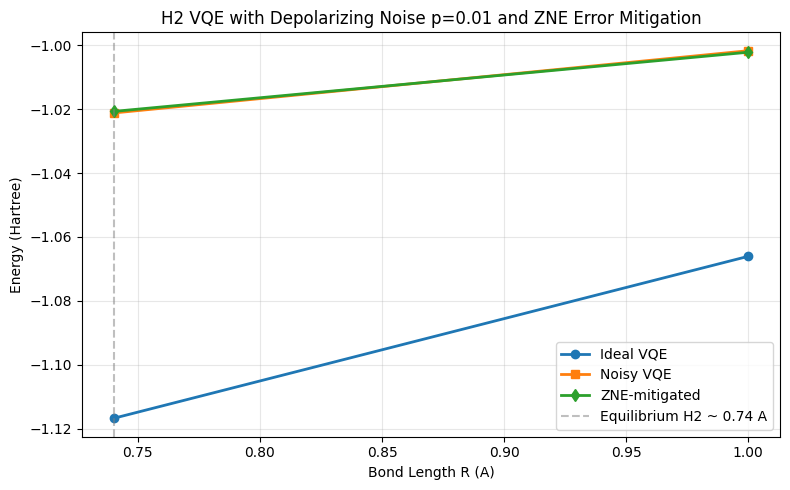

In [21]:
%pip install -q qiskit qiskit-nature pyscf qiskit-aer matplotlib pandas numpy tqdm scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.optimize import minimize
from IPython.display import display

from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit.circuit.library import TwoLocal
from qiskit_aer.primitives import Estimator
from qiskit_aer.noise import NoiseModel, depolarizing_error

np.random.seed(0)

# Configuration
R_list = [0.74, 1.00]
shots = 32000
p_error = 0.01

noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(depolarizing_error(p_error, 1), ["rx", "ry", "rz"])
noise_model.add_all_qubit_quantum_error(depolarizing_error(p_error, 2), ["cx"])

ideal_estimator = Estimator(run_options={"shots": None}, approximation=True)

noisy_estimator = Estimator(run_options={"shots": shots}, backend_options={"noise_model": noise_model})

mapper = JordanWignerMapper()


def get_energy(params, estimator, ansatz, hamiltonian):
    circuit = ansatz.assign_parameters(params)
    result = estimator.run([circuit], [hamiltonian]).result()
    return np.real(result.values[0])


def fold_global(circuit, scale):
    assert scale >= 1 and scale % 2 == 1
    if scale == 1:
        return circuit

    k = (scale - 1) // 2
    folded = circuit.copy()
    inverse = circuit.inverse()
    for _ in range(k):
        folded = folded.compose(inverse).compose(circuit)
    return folded


def noisy_energy_averaged(circuit, hamiltonian, n_repeats=20):
    vals = []
    for _ in range(n_repeats):
        e = noisy_estimator.run([circuit], [hamiltonian]).result().values[0]
        vals.append(np.real(e))
    return np.mean(vals), np.std(vals)


def zne_energy(circuit, hamiltonian, scales=(1, 3, 5), n_repeats=20, degree=1):
    energies = []
    for s in scales:
        folded = fold_global(circuit, s)
        mean_e, _ = noisy_energy_averaged(folded, hamiltonian, n_repeats=n_repeats)
        energies.append(mean_e)

    coeff = np.polyfit(scales, energies, deg=degree)
    zne_val = np.polyval(coeff, 0)

    if zne_val > energies[0]:
        return energies[0]
    return zne_val


data = []

for R in tqdm(R_list, desc="Running VQE"):

    driver = PySCFDriver(
        atom=f"H 0 0 0; H 0 0 {R}",
        basis="sto3g",
        unit=DistanceUnit.ANGSTROM
    )

    problem = driver.run()
    enuc = problem.hamiltonian.nuclear_repulsion_energy
    hamiltonian = mapper.map(problem.hamiltonian.second_q_op())
    n_qubits = hamiltonian.num_qubits

    ansatz = TwoLocal(
        num_qubits=n_qubits,
        rotation_blocks=["rx", "ry", "rz"],
        entanglement_blocks="cx",
        entanglement="linear",
        reps=1
    )

    initial_params = np.random.uniform(0, 2 * np.pi, ansatz.num_parameters)

    result_ideal = minimize(
        lambda p: get_energy(p, ideal_estimator, ansatz, hamiltonian),
        initial_params,
        method="COBYLA",
        options={"maxiter": 300}
    )

    ideal_params = result_ideal.x
    ideal_total = get_energy(ideal_params, ideal_estimator, ansatz, hamiltonian) + enuc

    circuit = ansatz.assign_parameters(ideal_params)

    noisy_mean, noisy_std = noisy_energy_averaged(circuit, hamiltonian, n_repeats=20)
    noisy_total = noisy_mean + enuc

    zne_val = zne_energy(circuit, hamiltonian, scales=(1, 3, 5), n_repeats=20, degree=1)
    zne_total = zne_val + enuc

    data.append([R, ideal_total, noisy_total, zne_total])

    print(
        f"R = {R:.2f} A | "
        f"Ideal = {ideal_total:.6f} | "
        f"Noisy = {noisy_total:.6f} | "
        f"ZNE = {zne_total:.6f} | "
        f"|ZNE-Ideal| < |Noisy-Ideal|: {abs(zne_total - ideal_total) < abs(noisy_total - ideal_total)}"
    )

df = pd.DataFrame(
    data,
    columns=["R (Angstrom)", "Ideal Energy", "Noisy Energy", "ZNE Energy"]
)
display(df.round(6))

plt.figure(figsize=(8, 5))
plt.plot(df["R (Angstrom)"], df["Ideal Energy"], "o-", label="Ideal VQE", linewidth=2)
plt.plot(df["R (Angstrom)"], df["Noisy Energy"], "s-", label="Noisy VQE", linewidth=2)
plt.plot(df["R (Angstrom)"], df["ZNE Energy"], "d-", label="ZNE-mitigated", linewidth=2)

plt.axvline(0.74, linestyle="--", color="gray", alpha=0.5, label="Equilibrium H2 ~ 0.74 A")

plt.xlabel("Bond Length R (A)")
plt.ylabel("Energy (Hartree)")
plt.title("H2 VQE with Depolarizing Noise p=0.01 and ZNE Error Mitigation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#16. Quantum Phase Estimation

Quantum Circuit Diagram:


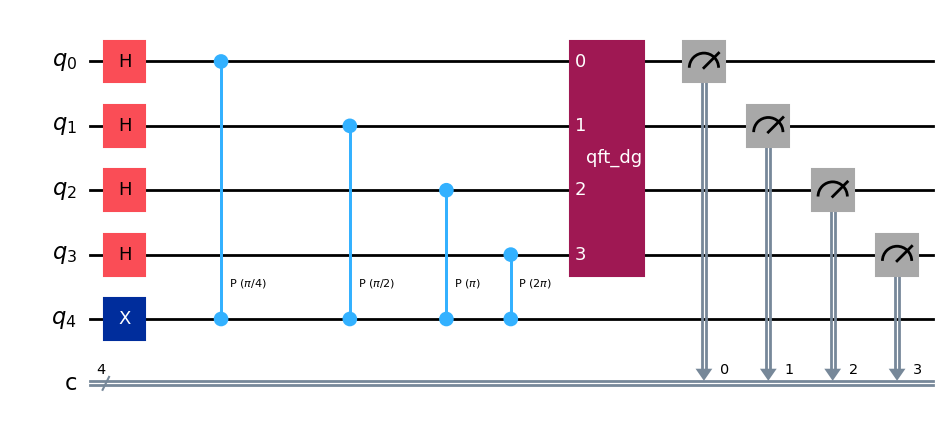

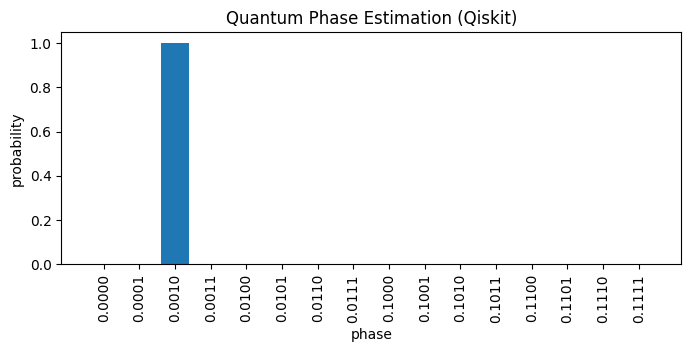

In [22]:
#%pip install -q qiskit qiskit-aer pylatexenc matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import PhaseGate, QFTGate
from qiskit_aer import AerSimulator

# Configuration
num_estimation_qubits = 4
total_qubits = num_estimation_qubits + 1  # 4 evaluation + 1 target qubit

# Single circuit initialization using default qubit indexing (q_0, q_1, ...)
qc = QuantumCircuit(total_qubits, num_estimation_qubits)

# Target qubit is index 4, estimation qubits are indices 0, 1, 2, 3
target_qubit = num_estimation_qubits  # q_4
eval_qubits = list(range(num_estimation_qubits))  # q_0, q_1, q_2, q_3

# 1. Initialize target qubit (q_4) to state |1>
qc.x(target_qubit)

# 2. Apply Hadamard gates to evaluation qubits (q_0..q_3)
for q in eval_qubits:
    qc.h(q)

# 3. Apply Controlled-U^(2^j) operations
theta = 2 * np.pi / 8

for j, eval_qubit in enumerate(eval_qubits):
    power = 2**j
    angle = power * theta

    gate_label = f"U^{power}" if power > 1 else "U"
    controlled_gate = PhaseGate(angle, label=gate_label).control(1)
    qc.append(controlled_gate, [eval_qubit, target_qubit])

# 4. Apply Inverse Quantum Fourier Transform (IQFTGate)
iqft_gate = QFTGate(num_qubits=num_estimation_qubits).inverse()
qc.append(iqft_gate, eval_qubits)

# 5. Measure evaluation qubits into classical bits
qc.measure(eval_qubits, list(range(num_estimation_qubits)))

# --- DISPLAY THE QUANTUM CIRCUIT ---
print("Quantum Circuit Diagram:")
display(qc.draw("mpl"))

# --- SIMULATE AND PLOT RESULTS ---
simulator = AerSimulator()
qc_transpiled = transpile(qc, simulator)

shots = 10000
result = simulator.run(qc_transpiled, shots=shots).result()
counts = result.get_counts()

# Process probabilities directly without extra string reversal
total_shots = sum(counts.values())
bit_strings = []
probabilities = []

for x in range(2**num_estimation_qubits):
    bitstr = f"{x:0{num_estimation_qubits}b}"
    prob = counts.get(bitstr, 0) / total_shots  # Direct lookup

    bit_strings.append(f"0.{bitstr}")
    probabilities.append(prob)

# Plotting phase probability distribution
plt.figure(figsize=(8, 4))
plt.bar(bit_strings, probabilities)
plt.xlabel("phase")
plt.ylabel("probability")
plt.xticks(rotation="vertical")
plt.title("Quantum Phase Estimation (Qiskit)")
plt.subplots_adjust(bottom=0.3)

plt.show()

#17. QPE for Molecular Energies

In [23]:
!pip install -q pyscf==2.11.0 qiskit==1.4.5 qiskit-nature==0.7.2 qiskit-aer==0.17.2 qiskit-algorithms pylatexenc

import numpy as np
import pandas as pd
from pyscf import gto, scf, fci

from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCC, HartreeFock
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import TwoLocal, QFT, DiagonalGate
from qiskit_algorithms import NumPyMinimumEigensolver, VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as AerEstimator

# ---------------------------------------------------------
# 0. Classical Reference: FCI via PySCF
# ---------------------------------------------------------
mol = gto.Mole()
mol.atom = '''
H 0 0 0.000
H 0 0 1.400
'''
mol.basis = 'sto-3g'
mol.charge = 0
mol.spin = 0
mol.unit = 'Bohr'
mol.build()

mf = scf.RHF(mol)
mf.kernel()

cisolver = fci.FCI(mol, mf.mo_coeff)
fci_energy = cisolver.kernel()[0]

# ---------------------------------------------------------
# 1. Molecular Driver Setup (Qiskit Nature)
# ---------------------------------------------------------
H2_driver = PySCFDriver(
    atom='H 0 0 0; H 0 0 1.4',
    basis='sto3g',
    charge=0,
    spin=0,
    unit=DistanceUnit.BOHR,
)
problem = H2_driver.run()
hamiltonian = problem.hamiltonian
second_q_op = hamiltonian.second_q_op()
enuc = hamiltonian.nuclear_repulsion_energy
num_spatial_orbitals = problem.num_spatial_orbitals
num_particles = problem.num_particles
qubit_op = JordanWignerMapper().map(second_q_ops=second_q_op)
n_qubits = qubit_op.num_qubits

# ---------------------------------------------------------
# 2. Reference Classical / NumPy Calculation
# ---------------------------------------------------------
numpy_solver = NumPyMinimumEigensolver()
numpy_res = numpy_solver.compute_minimum_eigenvalue(operator=qubit_op)
E_numpy = numpy_res.eigenvalue.real + enuc

# ---------------------------------------------------------
# 3. VQE with HEA
# ---------------------------------------------------------
backend = AerSimulator()
ansatz_HEA = TwoLocal(
    num_qubits=n_qubits,
    rotation_blocks="ry",
    entanglement_blocks="cx",
    entanglement='full',
    reps=3,
    insert_barriers=True,
    parameter_prefix='θ'
)
ansatz_HEA_t = transpile(ansatz_HEA, backend=backend, optimization_level=3)
vqe_HEA = VQE(AerEstimator(), ansatz_HEA_t, COBYLA())
res_HEA = vqe_HEA.compute_minimum_eigenvalue(operator=qubit_op)
E_HEA = res_HEA.optimal_value + enuc

# ---------------------------------------------------------
# 4. VQE with UCCSD
# ---------------------------------------------------------
init_state = HartreeFock(num_spatial_orbitals, num_particles, JordanWignerMapper())
ansatz_UCCSD = UCC(
    num_spatial_orbitals,
    num_particles,
    'sd',
    JordanWignerMapper(),
    initial_state=init_state
)
ansatz_UCCSD_t = transpile(ansatz_UCCSD, backend=backend, optimization_level=3)
vqe_UCCSD = VQE(AerEstimator(), ansatz_UCCSD_t, COBYLA())
res_UCCSD = vqe_UCCSD.compute_minimum_eigenvalue(operator=qubit_op)
E_UCCSD = res_UCCSD.optimal_value + enuc

# ---------------------------------------------------------
# 5. Quantum Phase Estimation (QPE) - exact evolution operator
# ---------------------------------------------------------
time = 0.25
num_evaluation_qubits = 10
n_system_qubits = n_qubits
n_total = num_evaluation_qubits + n_system_qubits
sys_qubits = list(range(num_evaluation_qubits, n_total))

H_mat = qubit_op.to_matrix()
evals_H, evecs_H = np.linalg.eigh(H_mat)
V = evecs_H
V_dag = V.conj().T

qc = QuantumCircuit(n_total)
qc.append(init_state.to_instruction(), sys_qubits)

for i in range(num_evaluation_qubits):
    qc.h(i)

for k in range(num_evaluation_qubits):
    power = 2 ** k
    phases = np.exp(-1j * evals_H * time * power)
    qc.unitary(V_dag, sys_qubits)
    cdg = DiagonalGate(phases).control(1)
    qc.append(cdg, [k] + sys_qubits)
    qc.unitary(V, sys_qubits)

iqft = QFT(num_qubits=num_evaluation_qubits, do_swaps=True, inverse=True)
qc.compose(iqft, range(num_evaluation_qubits), inplace=True)

qc_t = transpile(qc, basis_gates=['u3', 'cx'], optimization_level=0)

sim = AerSimulator(method='statevector')
qc_t.save_statevector()
qpe_result = sim.run(qc_t).result()
sv_qpe = qpe_result.data()['statevector']

probs_full = np.abs(sv_qpe.data) ** 2
eval_probs = np.zeros(2 ** num_evaluation_qubits)
for i, p in enumerate(probs_full):
    eval_probs[i & ((1 << num_evaluation_qubits) - 1)] += p

best = np.argmax(eval_probs)
phase = best / 2 ** num_evaluation_qubits

E_elec_candidates = [-2 * np.pi * (phase + s) / time for s in range(-3, 4)]
E_elec_qpe = min(E_elec_candidates, key=lambda E: abs(E - evals_H[0]))
E_qpe = E_elec_qpe + enuc

# ---------------------------------------------------------
# 6. Results Summary
# ---------------------------------------------------------
method_list = ['FCI', 'Numpy', 'HEA', 'UCCSD', 'QPE (no Trotterization)']
res_list = [fci_energy, E_numpy, E_HEA, E_UCCSD, E_qpe]
data = {
    'Method': method_list,
    'Result': res_list,
}
df = pd.DataFrame(data)
df.round(6)

converged SCF energy = -1.11671432506255


,Method,Result
0,FCI,-1.137276
1,Numpy,-1.137276
2,HEA,-1.134312
3,UCCSD,-1.137276
4,QPE (no Trotterization),-1.126491


In [24]:
import pyscf, qiskit, qiskit_nature, qiskit_aer, sys
txt = '{:15} : {:}'
print('Library Information')
print(txt.format('Python',sys.version.split()[0]))
print(txt.format('Numpy', np.__version__))
print(txt.format('PySCF', pyscf.__version__))
print(txt.format('Qiskit', qiskit.__version__))
print(txt.format('Qiskit Nature', qiskit_nature.__version__))
print(txt.format('Qiskit Aer', qiskit_aer.__version__))

Library Information
Python          : 3.12.13
Numpy           : 2.0.2
PySCF           : 2.11.0
Qiskit          : 1.4.5
Qiskit Nature   : 0.7.2
Qiskit Aer      : 0.17.2
